In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv("housing.csv")

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:\n", df.describe())

Shape: (20640, 10)

Missing Values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Data Types:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Statistical Summary:
           longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000  

In [10]:
df.fillna({"total_bedrooms": df["total_bedrooms"].median()}, inplace=True)

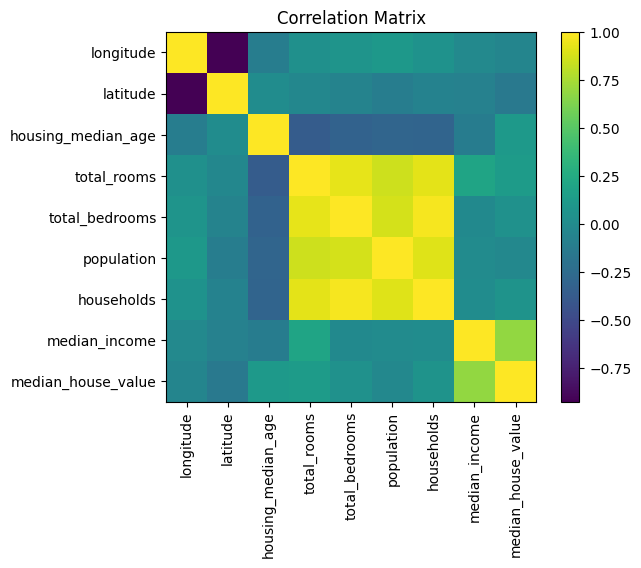


Correlation with Target (median_house_value):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [11]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation with Target (median_house_value):")
print(corr["median_house_value"].sort_values(ascending=False))

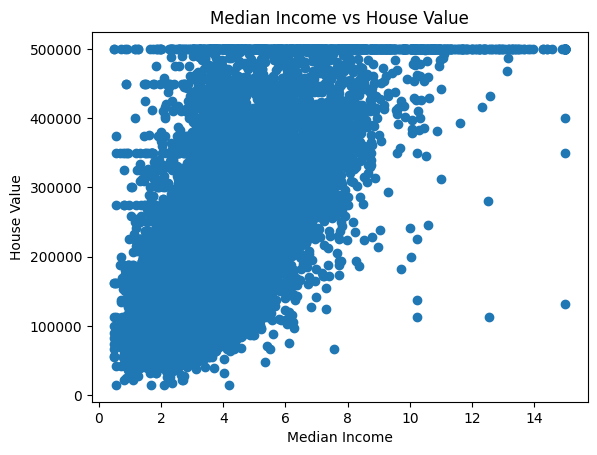

In [12]:
plt.figure()
plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Median Income vs House Value")
plt.show()

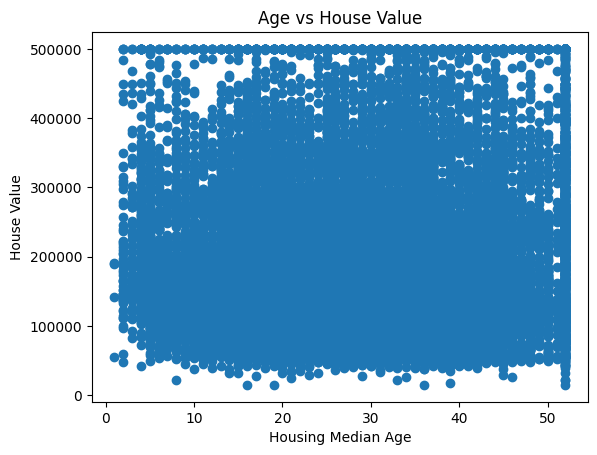

In [13]:
plt.figure()
plt.scatter(df["housing_median_age"], df["median_house_value"])
plt.xlabel("Housing Median Age")
plt.ylabel("House Value")
plt.title("Age vs House Value")
plt.show()

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
X = df_encoded.drop("median_house_value", axis=1)
y = df_encoded["median_house_value"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression
MSE: 4908041658.447793
R2 Score: 0.6254572625840541


In [19]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("\nLasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression
MSE: 4908475779.947156
R2 Score: 0.6254241338809872


In [20]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coeff_df)

                       Feature         Ridge         Lasso
0                    longitude -53713.651593 -53826.359145
1                     latitude -54298.400415 -54415.406029
2           housing_median_age  13890.472329  13889.859513
3                  total_rooms -13058.643741 -13094.040844
4               total_bedrooms  42978.328403  43067.954114
5                   population -43389.968779 -43403.359260
6                   households  18425.412550  18382.149926
7                median_income  75157.635752  75167.725268
8       ocean_proximity_INLAND -18538.725530 -18506.181176
9       ocean_proximity_ISLAND   2119.249166   2118.429656
10    ocean_proximity_NEAR BAY  -1616.222261  -1621.672205
11  ocean_proximity_NEAR OCEAN   1146.564026   1139.916142


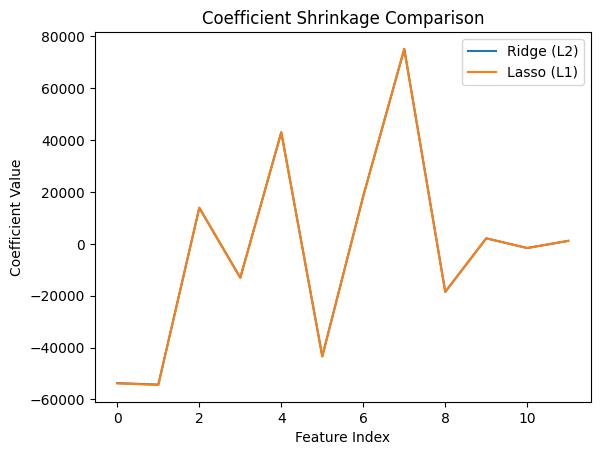

In [21]:
plt.figure()
plt.plot(ridge.coef_, label="Ridge (L2)")
plt.plot(lasso.coef_, label="Lasso (L1)")
plt.legend()
plt.title("Coefficient Shrinkage Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()